# Statistical Analysis of the Iris Dataset

***Student Name:** Anirudh Jagirdar

***University:** SRH University Heidelberg

***Course:** Master's in Applied Data Science and AI

***Assignment:** Week 1 Individual Assignment



## Objective
This project demonstrates descriptive and inferential statistical analysis using the Iris dataset.

## Techniques Used

- Data inspection
- Summary statistics
- Mean
- Variance
- Standard deviation
- Histogram
- Boxplot
- Scatter plot
- Skewness
- Correlation analysis
- Independent t-test
- One-way ANOVA

## Libraries

- pandas
- numpy
- matplotlib
- seaborn
- scipy
- scikit-learn

## Results

The analysis showed strong correlations among petal measurements and statistically significant differences between Iris species according to both the t-test and ANOVA.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

## 2. Load Dataset

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Dataset Overview

The Iris dataset is a well-known dataset used for statistical analysis and machine learning. It contains 150 flower samples with four numerical features and one target variable representing three Iris species.

## 3. Dataset Inspection and Summary

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### Interpretation

The Iris dataset contains 150 observations and 5 columns. Four columns are numerical measurements of flowers, while the target column represents the species. There are no missing values, making the dataset suitable for statistical analysis.

In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
df.shape

(150, 5)

In [6]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


## 4. Identify Variable Types

In [7]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64


### Variable Types

The dataset contains four numerical variables:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target column is a categorical variable representing three Iris species.

## 5. Mean, Variance and Standard Deviation

In [8]:
numeric = df.iloc[:,0:4]

summary = pd.DataFrame({
    "Mean":numeric.mean(),
    "Variance":numeric.var(),
    "Std Dev":numeric.std()
})

summary

,Mean,Variance,Std Dev
sepal length (cm),5.843333,0.685694,0.828066
sepal width (cm),3.057333,0.189979,0.435866
petal length (cm),3.758000,3.116278,1.765298
petal width (cm),1.199333,0.581006,0.762238


### Interpretation

The summary statistics show the average, variance, and standard deviation for each numerical feature. Petal length has the highest variance and standard deviation, indicating greater variability, while sepal width has the lowest variability.

## 6. Histogram

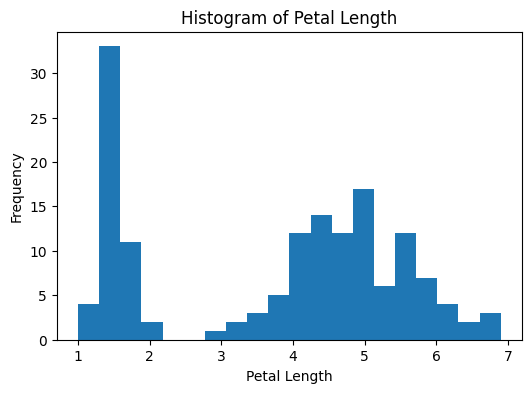

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["petal length (cm)"], bins=20)
plt.title("Histogram of Petal Length")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()

### Interpretation

The histogram shows the distribution of petal length. The data appears to form multiple clusters, suggesting differences among the three Iris species.

## 7. Boxplot

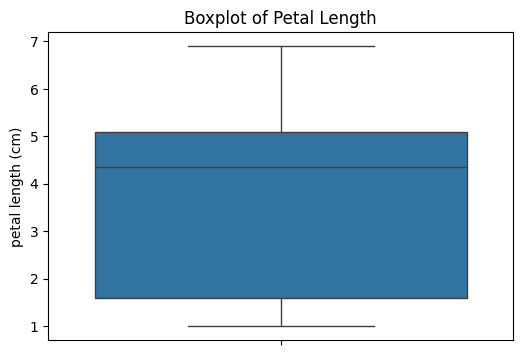

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["petal length (cm)"])
plt.title("Boxplot of Petal Length")
plt.show()

### Interpretation

The boxplot displays the median, spread, and possible outliers of petal length. It helps visualize the distribution and variability of the data.

## 8. Scatter Plot

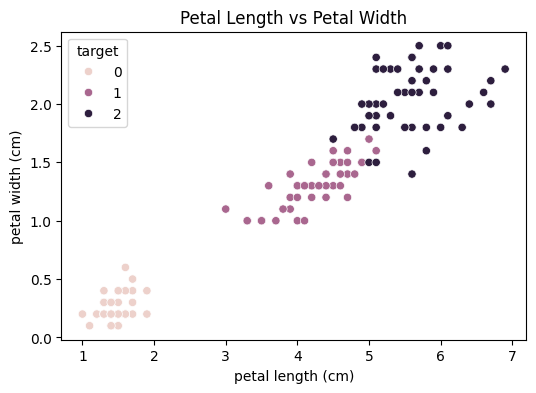

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="target"
)
plt.title("Petal Length vs Petal Width")
plt.show()

### Interpretation

The scatter plot shows a strong positive relationship between petal length and petal width. The three Iris species form distinct clusters, making them easy to distinguish.

## 9. Distribution and Skewness

In [12]:
for col in numeric.columns:
    print(col, skew(df[col]))

sepal length (cm) 0.3117530585022963
sepal width (cm) 0.31576710633893473
petal length (cm) -0.2721276664567214
petal width (cm) -0.10193420656560036


### Interpretation

Sepal length and sepal width show slight positive skewness, while petal length and petal width show slight negative skewness. Since all skewness values are close to zero, the distributions are approximately symmetric.

## 10. Correlation Analysis

In [13]:
corr = numeric.corr()

corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


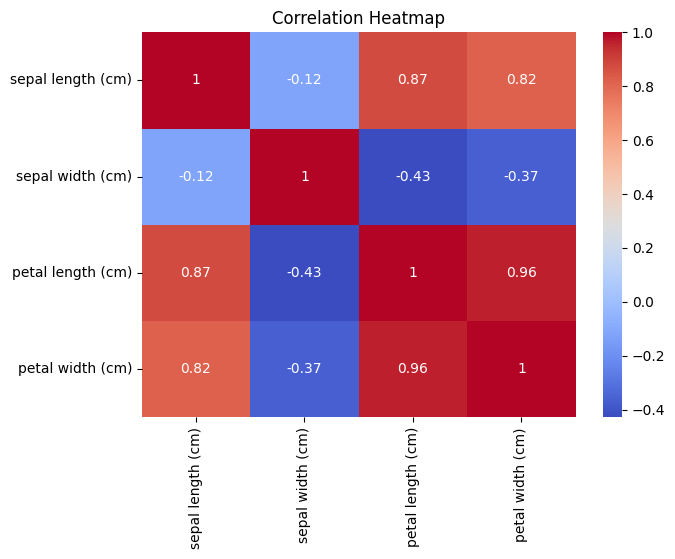

In [20]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The correlation heatmap shows that petal length and petal width have a very strong positive correlation. This means flowers with longer petals generally have wider petals.

## 11. Independent t-test

In [15]:
group1 = df[df.target==0]["petal length (cm)"]
group2 = df[df.target==1]["petal length (cm)"]

t_stat,p = ttest_ind(group1,group2)

print(t_stat)
print(p)

-39.492719391538095
5.404910513441677e-62


### Interpretation

The p-value is much smaller than 0.05, so the null hypothesis is rejected. There is a statistically significant difference in the mean petal length between Species 0 and Species 1.

## 12. One-way ANOVA

In [22]:
# Select petal length for each species
g1 = df[df.target == 0]["petal length (cm)"]
g2 = df[df.target == 1]["petal length (cm)"]
g3 = df[df.target == 2]["petal length (cm)"]

# Perform One-way ANOVA
F, p = f_oneway(g1, g2, g3)

# Display the results
print("F-statistic:", F)
print("P-value:", p)

F-statistic: 1180.1611822529785
P-value: 2.8567766109619814e-91


### Interpretation

The ANOVA test returned a p-value less than 0.05, indicating that at least one of the three Iris species has a significantly different mean petal length.

## 13. Conclusion

The Iris dataset was analyzed using descriptive and inferential statistical techniques. Descriptive statistics showed that petal measurements exhibited greater variability than sepal measurements. Visualizations highlighted distinct differences among species, particularly in petal dimensions. Correlation analysis revealed a strong positive relationship between petal length and petal width. Both the independent t-test and ANOVA demonstrated statistically significant differences in petal length among species. Overall, petal measurements are highly effective for distinguishing Iris species.